# Contextualize group difference in stim1-2 activation differences on grad3-bins

1. specific region? --> plot on surface
2. would standard GLM have found this?
3. Does it correlate with the found group differences in connectivity?
    * NPC specific or other DAN region??

In [ ]:
# calculating similarity of beta-activation of stim 1/2 with grad per sub and then correlating that to behavior

import pandas as pd
import os.path as op
import numpy as np
import os
from pathlib import Path
from scipy.stats import pearsonr
import nilearn.plotting as nplt
import nibabel as nib
import glob

from parietal_patterns.utils.surfaces import get_basic_mask
mask, _ = get_basic_mask()

BIDS_ROOT_LARGE  = '/mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/ds-dnumrisk'
BIDS_ORIG        = '/mnt_03/ds-dnumrisk'

phenotype_folder = op.join(BIDS_ROOT_LARGE, 'derivatives','phenotype')
gradient_folder = op.join(BIDS_ROOT_LARGE, 'derivatives','gradients.tryParams.36P')
activation_folder= op.join(BIDS_ROOT_LARGE, 'derivatives','average_act.glm','mean_maps_nan_filtered.glm')
# /mean_maps.glm --> normal .gii
subList = [f'{sub:02}' for sub in range(1, 67)]

group_df = pd.read_csv(op.join(BIDS_ROOT_LARGE, 'group_assignment.csv')).set_index('subject')


## Further specifications of activity diff (group) of diff (stim) on grad-3 finding

In [28]:
grad_dir = gradient_folder
in_dir = activation_folder

grad_nrs = [1, 2, 3]
n_bins = 20

stimuli = ['1', '2']

n_vertices = 18715

sub_dfs = []

for sub in subList:
    #grad_vec_unmask = np.load(op.join(grad_dir, f'sub-{sub}', f'sub-{sub}_g-aligned-tanH_kernel-normalized_angle_ztransf-True_ccfilter.npy'))
    sub_file_pattern = op.join(grad_dir, f'sub-{sub}', f'sub-{sub}_g-aligned-tanH_kernel-normalized_angle_ztransf-True*.npy') 
    fn = glob.glob(sub_file_pattern)[0]
    grad_vec_unmask= np.load(fn)
    
    sub_data = {}

    for grad_nr in grad_nrs:
        grad_vec = grad_vec_unmask[grad_nr - 1][mask]
        bin_edges = np.linspace(np.nanmin(grad_vec), np.nanmax(grad_vec), n_bins + 1)
        sub_data[f'grad{grad_nr}'] = grad_vec
        sub_data[f'grad{grad_nr}_bin'] = np.clip(
            np.digitize(grad_vec, bin_edges, right=True) - 1, 0, n_bins - 1
        )

    for stim in stimuli:
        fpath = op.join(in_dir, f'stim-{stim}', f'sub-{sub}',
                        f'sub-{sub}_stim-{stim}_masked_nan_filtered.npy')
        sub_data[f'stim{stim}'] = np.load(fpath)

    sub_dfs.append(pd.DataFrame(sub_data))

df_grads_stims = pd.concat(sub_dfs, keys=np.array(subList).astype(int), names=['subject', 'i_vertex'])


In [50]:
import seaborn as sns
import matplotlib.pyplot as plt

color_stim1 = '#053061'
color_stim2 = '#b2182b'

In [48]:
tmp.head()

mean_activation
subject grad1_bin stim                  
1       0         stim1         0.143233
                  stim2         0.115848
        1         stim1         0.086808
                  stim2         0.083741
        2         stim1         0.068690

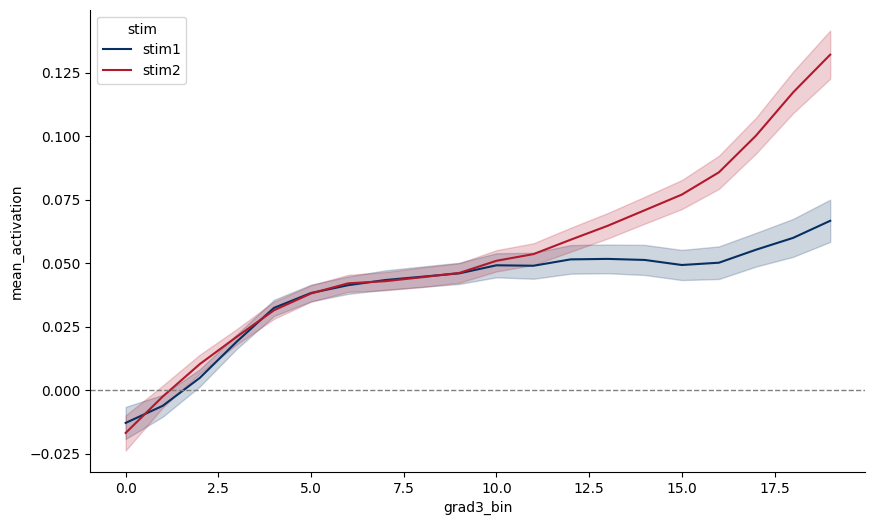

In [53]:
i_grad_bin = 3
tmp = df_grads_stims.groupby(['subject', f'grad{i_grad_bin}_bin'])[['stim1', 'stim2']].mean()#.reset_index()
tmp = pd.DataFrame(tmp.stack(), columns=['mean_activation']) 
tmp.index.names = ['subject', f'grad{i_grad_bin}_bin', 'stim']

fig, ax = plt.subplots(figsize=(10, 6))

sns.lineplot(data=tmp.reset_index(), 
             x=f'grad{i_grad_bin}_bin', 
             y='mean_activation', 
             hue='stim', 
            palette=[color_stim1, color_stim2],
            errorbar='se',
            ax=ax)
ax.axhline(0, color='gray', linestyle='--', linewidth=1)
sns.despine()

Text(0.5, 0.98, 'Mean stim2 - stim1 activation across subjects')

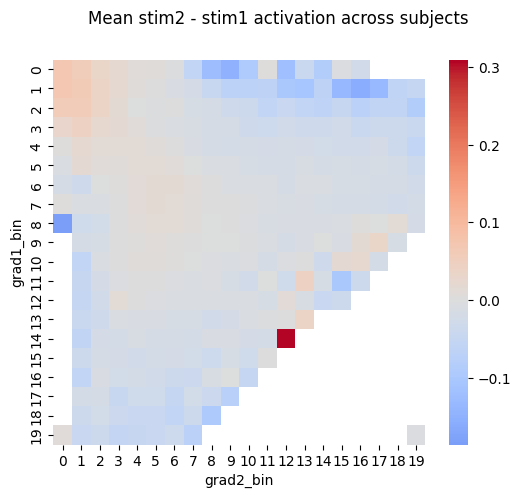

In [98]:
# 2D gradient bins

i_grad_bin1 = 1
i_grad_bin2 = 2

tmp = df_grads_stims.groupby(['subject', f'grad{i_grad_bin1}_bin', f'grad{i_grad_bin2}_bin'])[['stim1', 'stim2']].mean()#.reset_index()
tmp['stim_diff'] = tmp['stim2'] - tmp['stim1']

tmp_tmp = tmp['stim_diff'].groupby([f'grad{i_grad_bin1}_bin', f'grad{i_grad_bin2}_bin']).mean().unstack()
fig, ax = plt.subplots(figsize=(6,5))
sns.heatmap(tmp_tmp, cmap='coolwarm', center=0, ax=ax)
fig.suptitle('Mean stim2 - stim1 activation across subjects')

Text(0.5, 0.98, 'Mean vertex count per 2D gradient bin across subjects')

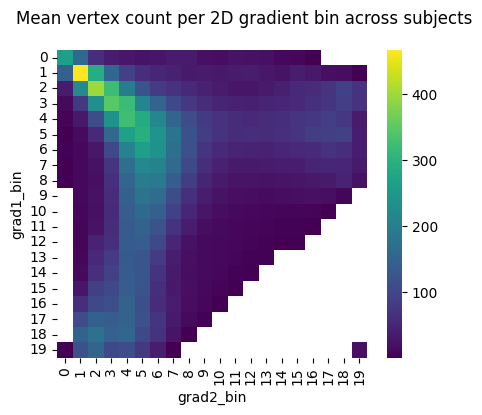

In [99]:
vertex_counts = (
    df_grads_stims
    .groupby(['subject', f'grad{i_grad_bin1}_bin', f'grad{i_grad_bin2}_bin'])
    .size()
    .groupby([f'grad{i_grad_bin1}_bin', f'grad{i_grad_bin2}_bin'])
    .mean()
    .unstack()
)

fig, ax = plt.subplots(figsize=(5,4))
sns.heatmap(vertex_counts, cmap='viridis', ax=ax)
fig.suptitle('Mean vertex count per 2D gradient bin across subjects')


Text(0.5, 0.98, 'Mean stim2 - stim1 activation subject 5')

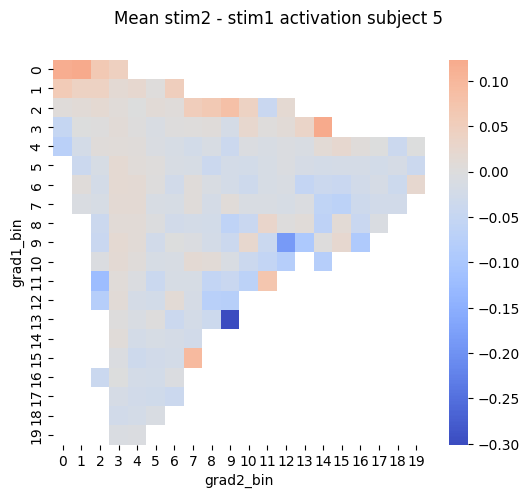

In [107]:
sub = 5
tmp_tmp = tmp['stim_diff'].xs(sub, level='subject').unstack()
fig, ax = plt.subplots(figsize=(6,5))
sns.heatmap(tmp_tmp, cmap='coolwarm', center=0, ax=ax)
fig.suptitle(f'Mean stim2 - stim1 activation subject {sub}')

<Axes: xlabel='grad3_bin', ylabel='stim_diff'>

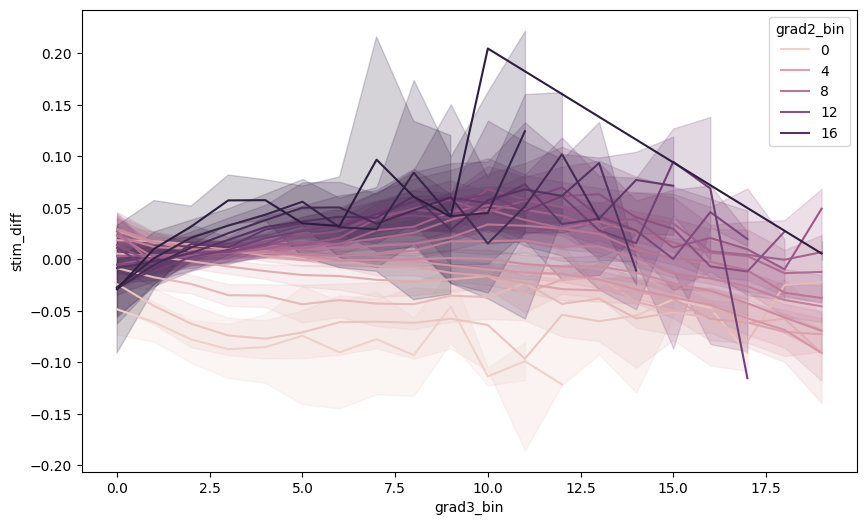

In [61]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.lineplot(data=tmp.reset_index(), 
             x=f'grad{i_grad_bin2}_bin',
             y='stim_diff',
             hue=f'grad{i_grad_bin1}_bin',
            ax=ax)

In [ ]:
fig, ax = plt.subplots(figsize=(5,5))

sns.heatmap(tmp['stim_diff'], 


## Correlation of previous connectivity measures with act-gradient-correlations

Is there a relationship with the activity findings (respecting individual functional anatomy) with the connectivty findings

In [2]:
# non binned correlations

grad_nr = 3
spec = 'g-aligned'
kernel = 'normalized_angle'

aligned = 'av.timeseries-aligned'
flipped = '_flipped' 
#n_bins = 20

stimuli = ['1', '2']

corrs = {'sub': [],
         'corr_1': [], 'pval_1': [],
         'corr_2': [], 'pval_2': []}


for sub in subList:
    
    folder = Path(gradient_folder) / f'sub-{sub}'
    base = f"sub-{sub}_g-aligned-tanH_kernel-normalized_angle_ztransf-True"

    for suffix in ["_ccfilter", ""]:
        filepath = folder / f"{base}{suffix}.npy"
        if filepath.exists():
            data = np.load(filepath)
            #print(f"Loaded: {filepath.name}")
            break
    else:
        # show what IS there to debug
        folder = Path(gradient_folder) / f'sub-{sub}'
        print(f"No file found for sub-{sub}. Files present: {list(folder.glob('*.npy'))}")
        continue  # skip this subject explicitly

    # lading grads
    grad_vec_unmask = data
    grad_vec = grad_vec_unmask[grad_nr-1][mask]

    corrs['sub'].append(sub)

    for stim in stimuli:

        # load masked_mean_maps
        fname = f"sub-{sub}_stim-{stim}_masked_nan_filtered.npy"
        fpath = op.join(activation_folder,f'stim-{stim}', f'sub-{sub}', fname)
        masked = np.load(fpath)
        masked_mean_maps = masked

        valid = ~np.isnan(grad_vec) & ~np.isnan(masked_mean_maps)

        # correlate grad and beta map
        stat, pval = pearsonr(masked_mean_maps[valid], grad_vec[valid])

        corrs[f'corr_{stim}'].append(stat)
        corrs[f'pval_{stim}'].append(pval)
    
            
df_corrs = pd.DataFrame(corrs)
df_corrs['subject'] = df_corrs['sub'].astype(int)

In [3]:
df_grad_beta_corr = df_corrs.set_index('subject').drop(columns=['sub', 'pval_1', 'pval_2'])
df_grad_beta_corr['corr_diff'] = df_grad_beta_corr['corr_2'] - df_grad_beta_corr['corr_1']

In [4]:
df_parietalDANpatch_size = pd.read_csv(op.join(phenotype_folder, 'netsPFM_DANpatches.csv'))
df_parietalDANpatch_size = df_parietalDANpatch_size.rename(columns={'sub_id':'subject'}).set_index(['subject','patch'])
area_measure = 'ind_area' #
df_parietalDANpatch_size = df_parietalDANpatch_size[area_measure].unstack('patch')
df_parietalDANpatch_size.head()

patch,L_frontal-lateral,L_parietal-lateral,L_temporal,R_frontal-lateral,R_parietal-lateral,R_temporal
subject,,,,,,
1,2893.85500,4814.7020,1832.93100,4589.0044,5347.0740,1433.9761
2,1004.00916,4049.3140,1082.97000,3094.5550,4547.2610,1418.6052
3,2036.32470,4691.3325,867.63965,2567.5078,5833.8623,1008.5117
4,3449.32400,6723.5650,1706.00920,2596.2368,5537.7275,1230.2832
6,1412.71400,3985.4292,886.12244,2401.5800,4696.7046,1237.0745


In [5]:
df_comb = df_parietalDANpatch_size.join(df_grad_beta_corr)
df_comb.corr()  


,L_frontal-lateral,L_parietal-lateral,L_temporal,R_frontal-lateral,R_parietal-lateral,R_temporal,corr_1,corr_2,corr_diff
L_frontal-lateral,1.000000,0.482198,0.034222,0.327200,0.425579,-0.000506,0.139078,0.072878,-0.074412
L_parietal-lateral,0.482198,1.000000,0.251559,0.100987,0.790779,0.193400,0.087944,-0.032708,-0.138149
L_temporal,0.034222,0.251559,1.000000,-0.059552,0.150207,0.547722,0.005444,-0.123017,-0.146037
R_frontal-lateral,0.327200,0.100987,-0.059552,1.000000,0.350594,0.082774,0.039547,0.134389,0.112499
R_parietal-lateral,0.425579,0.790779,0.150207,0.350594,1.000000,0.219629,0.054081,-0.112658,-0.190114
R_temporal,-0.000506,0.193400,0.547722,0.082774,0.219629,1.000000,-0.050229,-0.105117,-0.061293
corr_1,0.139078,0.087944,0.005444,0.039547,0.054081,-0.050229,1.000000,0.616850,-0.447322
corr_2,0.072878,-0.032708,-0.123017,0.134389,-0.112658,-0.105117,0.616850,1.000000,0.428014
corr_diff,-0.074412,-0.138149,-0.146037,0.112499,-0.190114,-0.061293,-0.447322,0.428014,1.000000


In [ ]:
activation_folder= op.join(BIDS_ROOT_LARGE, 'derivatives','average_act.glm','mean_maps.glm')

sub = '01'
stim = '1'
hemi = 'R'
fname = f"sub-{sub}_ses-1_task-magjudge_space-fsaverage5_stim-{stim}_hemi-{hemi}_average.func.gii"

surf_map = nib.load(op.join(activation_folder,f'stim-{stim}', f'sub-{sub}', fname)).darrays[0].data

# filter with 95% confidence interval of the distribution of values across all subjects and both stimuli
lower_threshold = -1.31
upper_threshold = 1.42
nan_mask = (surf_map < lower_threshold) | (surf_map > upper_threshold)

surf_map[nan_mask] = np.nan


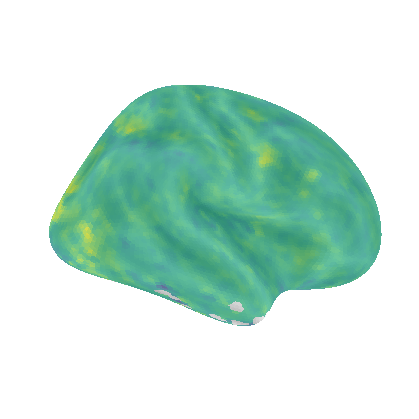

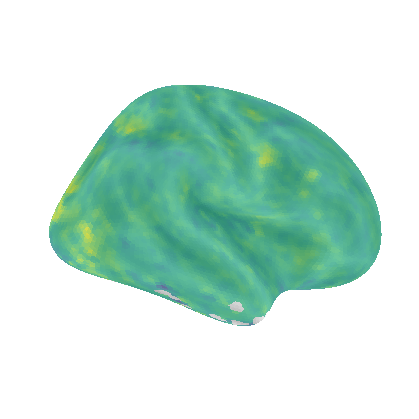

In [44]:
from  nilearn.datasets import fetch_surf_fsaverage

fsaverage = fetch_surf_fsaverage() # default 5

nplt.plot_surf(surf_mesh= fsaverage.infl_right, 
            surf_map= surf_map, # infl_right # pial_right
            view= 'medial',
            #cmap=cmap, 
            colorbar=False,  # sub-{sub}, title=f’grad {i+1}‘,
            bg_map=fsaverage.sulc_right, bg_on_data=True,darkness=0.7) #



In [ ]:
gm = np.split(grad_vec,2) # for i, hemi in enumerate([‘L’, ‘R’]): --> left first
gm_r = gm[1]

## Group comparison on surface (2-sample t-test)

Load the surface activation maps for all subjects and run a vertex-wise
Welch two-sample t-test (group 0 vs group 1) with FDR correction.

**`condition`** controls what is tested:
- `'stim1'`  — activation to stimulus 1
- `'stim2'`  — activation to stimulus 2
- `'diff'`   — stim 2 − stim 1 (default: mirrors the notebook topic)

In [18]:
import matplotlib.pyplot as plt
from nilearn.datasets import fetch_surf_fsaverage

# ── choose condition ──────────────────────────────────────────────────────────
condition = 'stim1'   # 'stim1' | 'stim2' | 'diff'
# ─────────────────────────────────────────────────────────────────────────────

# reuse thresholds and activation folder defined in the single-subject cell above
lower_threshold = -1.31
upper_threshold  =  1.42
act_folder_surf = op.join(BIDS_ROOT_LARGE, 'derivatives',
                          'average_act.glm', 'mean_maps.glm')

surf_maps_all = []
valid_subs    = []

for sub in subList:
    try:
        maps = {}
        for stim in ['1', '2']:
            hemi_maps = []
            for hemi in ['L', 'R']:
                fname = (f"sub-{sub}_ses-1_task-magjudge_space-fsaverage5"
                         f"_stim-{stim}_hemi-{hemi}_average.func.gii")
                fpath = op.join(act_folder_surf, f'stim-{stim}', f'sub-{sub}', fname)
                d = nib.load(fpath).darrays[0].data.astype(float)
                # same 95 % CI outlier filter as single-subject cell
                d[(d < lower_threshold) | (d > upper_threshold)] = np.nan
                hemi_maps.append(d)
            maps[stim] = np.concatenate(hemi_maps)  # L then R (matches grad_vec convention)

        if   condition == 'stim1': surf_map_sub = maps['1']
        elif condition == 'stim2': surf_map_sub = maps['2']
        elif condition == 'diff':  surf_map_sub = maps['2'] - maps['1']

        surf_maps_all.append(surf_map_sub)
        valid_subs.append(int(sub))

    except FileNotFoundError as e:
        print(f"Skipping sub-{sub}: {e}")

surf_maps_all = np.array(surf_maps_all)          # (n_subs, n_vertices)
sub_array     = np.array(valid_subs)
groups        = group_df.loc[sub_array, 'group'].values

group_0_maps  = surf_maps_all[groups == 0]
group_1_maps  = surf_maps_all[groups == 1]
print(f"condition = '{condition}' | map shape: {surf_maps_all.shape}")
print(f"Group 0: {group_0_maps.shape[0]} subjects  |  Group 1: {group_1_maps.shape[0]} subjects")

Skipping sub-03: No such file or no access: '/mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/ds-dnumrisk/derivatives/average_act.glm/mean_maps.glm/stim-1/sub-03/sub-03_ses-1_task-magjudge_space-fsaverage5_stim-1_hemi-L_average.func.gii'
condition = 'stim1' | map shape: (65, 20484)
Group 0: 32 subjects  |  Group 1: 33 subjects


In [19]:
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests

# vertex-wise Welch two-sample t-test
t_stats, p_values = ttest_ind(group_0_maps, group_1_maps,
                              axis=0, equal_var=False, nan_policy='omit')

# FDR correction (Benjamini–Hochberg) over valid (non-NaN) vertices
valid_mask = ~np.isnan(p_values)
p_fdr = np.full_like(p_values, np.nan)
p_fdr[valid_mask] = multipletests(p_values[valid_mask], method='fdr_bh')[1]

print(f"Uncorrected  p < 0.05 : {np.nansum(p_values < 0.05):4d} vertices")
print(f"FDR-corrected p < 0.05 : {np.nansum(p_fdr   < 0.05):4d} vertices")

Uncorrected  p < 0.05 : 1273 vertices
FDR-corrected p < 0.05 :    0 vertices


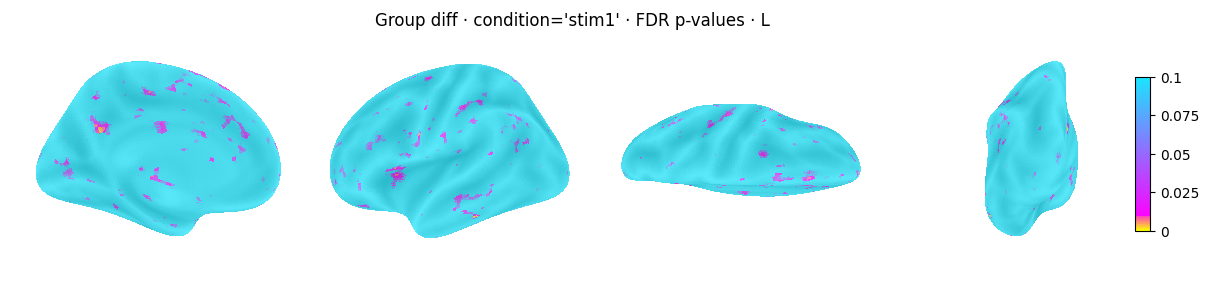

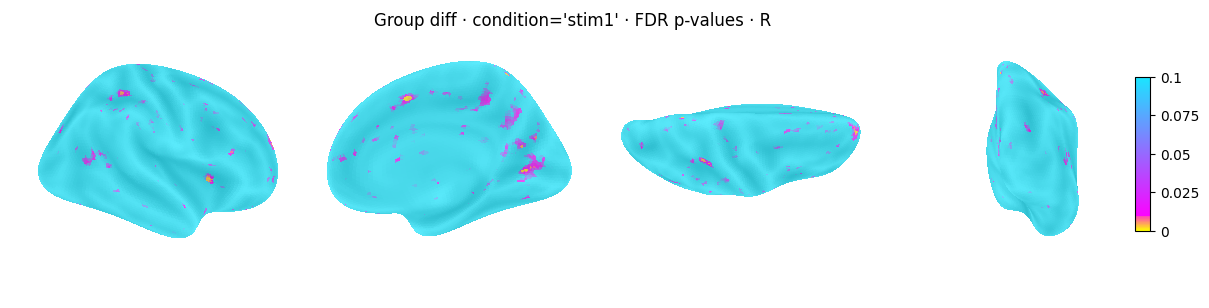

In [20]:
# ── plot FDR-corrected p-values on surface ────────────────────────────────────
fsaverage = fetch_surf_fsaverage()   # fsaverage5 (already loaded above if cell 7 ran)
views     = ['medial', 'lateral', 'dorsal', 'posterior']

from parietal_patterns.utils.statistics import get_pval_colormap

pval_cmap = get_pval_colormap()              # low p (significant) = bright/yellow

for i, hemi in enumerate(['L', 'R']):
    surf_map_plot = np.split(p_values, 2)[i]
    surf_mesh = fsaverage.infl_right if hemi == 'R' else fsaverage.infl_left
    bg_map    = fsaverage.sulc_right  if hemi == 'R' else fsaverage.sulc_left

    fig, axes = plt.subplots(1, len(views), figsize=(15, 4),
                             subplot_kw=dict(projection='3d'))
    for j, view in enumerate(views):
        nplt.plot_surf(surf_mesh=surf_mesh, surf_map=surf_map_plot,
                       vmin=0, vmax=0.1,
                       view=view, cmap=pval_cmap,
                       colorbar=(view == 'posterior'),
                       bg_map=bg_map, bg_on_data=True, darkness=0.7,
                       axes=axes[j])
    fig.subplots_adjust(wspace=0.01)
    fig.suptitle(f"Group diff · condition='{condition}' · FDR p-values · {hemi}", y=0.85)
plt.show()

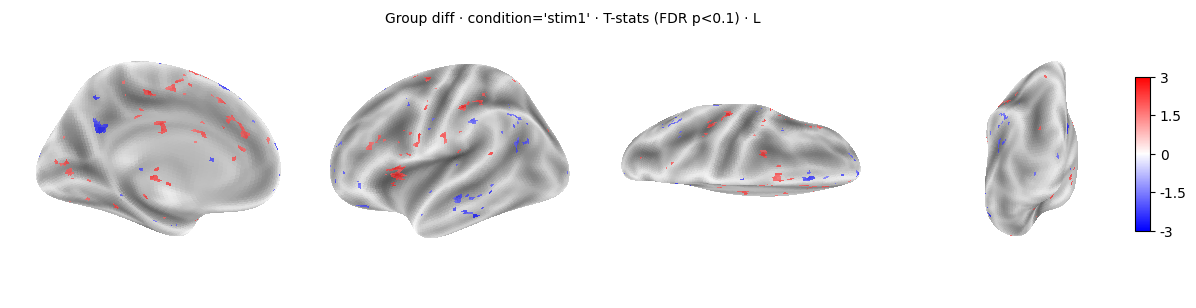

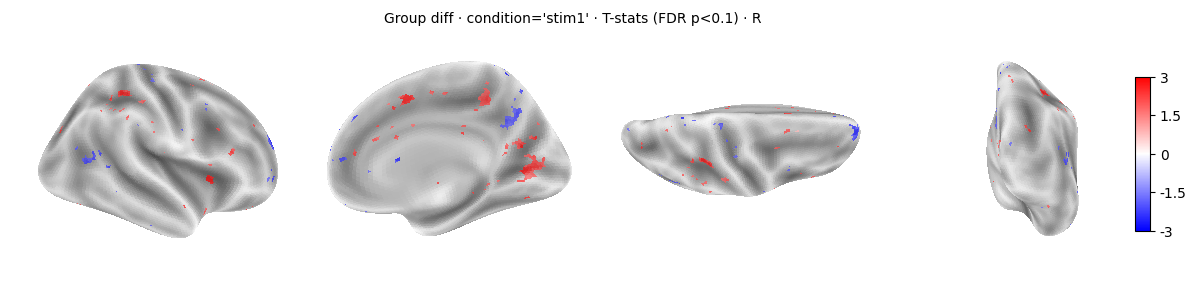

In [21]:
# ── plot t-statistics thresholded at p < thresh ──────────────────────────
tstat_cmap = 'bwr'
thresh     = 0.1

t_thresh = t_stats.copy()
t_thresh[~(p_values < thresh)] = np.nan   # keep only significant vertices

for i, hemi in enumerate(['L', 'R']):
    surf_map_plot = np.split(t_thresh, 2)[i]
    surf_mesh = fsaverage.infl_right if hemi == 'R' else fsaverage.infl_left
    bg_map    = fsaverage.sulc_right  if hemi == 'R' else fsaverage.sulc_left

    fig, axes = plt.subplots(1, len(views), figsize=(15, 4),
                             subplot_kw=dict(projection='3d'))
    for j, view in enumerate(views):
        nplt.plot_surf(surf_mesh=surf_mesh, surf_map=surf_map_plot,
                       vmin=-3, vmax=3,
                       view=view, cmap=tstat_cmap,
                       colorbar=(view == 'posterior'),
                       bg_map=bg_map, bg_on_data=True, darkness=0.7,
                       axes=axes[j])
    fig.subplots_adjust(wspace=0.01)
    fig.suptitle(f"Group diff · condition='{condition}' · T-stats (FDR p<{thresh}) · {hemi}",
                 y=0.85, fontsize=10)
plt.show()